In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel("data/raw_data/Blinkit_Sales_Data.xlsx")

# 1. Basic Understanding of Data

In [8]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [25]:
df.sample(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8440,NCO29,11.15,Low Fat,0.032388,Health and Hygiene,164.3526,OUT018,2009,Medium,Tier 3,Supermarket Type2,2960.1468
5673,FDH05,14.35,Regular,0.090914,Frozen Foods,231.2984,OUT046,1997,Small,Tier 1,Supermarket Type1,3243.7776
6331,FDA38,5.44,Low Fat,0.025459,Dairy,241.2538,OUT013,1987,High,Tier 3,Supermarket Type1,3124.5994
2183,DRE15,13.35,Low Fat,0.017858,Dairy,77.5012,OUT018,2009,Medium,Tier 3,Supermarket Type2,1518.0240
3862,DRM59,5.88,Low Fat,0.003589,Hard Drinks,155.5998,OUT013,1987,High,Tier 3,Supermarket Type1,1691.7978


In [9]:
df.shape

(8523, 12)

In [10]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [11]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [45]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

# 2. Data Cleaning

In [12]:
# Handling Missing Values - (Item_Weight Numerical Column)

# Fill missing values in Item_Weight using the median.
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].median())

# Check remaining missing values
print("Missing values in Item_Weight:", df['Item_Weight'].isnull().sum())

Missing values in Item_Weight: 0


In [13]:
# Handle Outlet_Size - (categorical Column)

# Fill missing values in Outlet_Size using the mode 
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

# Check missing values
print("Missing values in Outlet_Size:", df['Outlet_Size'].isnull().sum())

Missing values in Outlet_Size: 0


In [14]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

## 3. Save Cleaned Data

In [30]:
df.to_excel("data/clean_data/Blinkit_Sales_Data_Clean.xlsx", index=False)

# 4. Exploratory Data Analysis (EDA)
### 1. Basic Overview

In [15]:
print(df.info())
print()
print(df.describe())
print()
print(df['Item_Type'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB
None

       Item_Weight  Item_Visibility    

This will help you understand the structure and distribution of the dataset.

### 2. Univariate Analysis (Single Column)

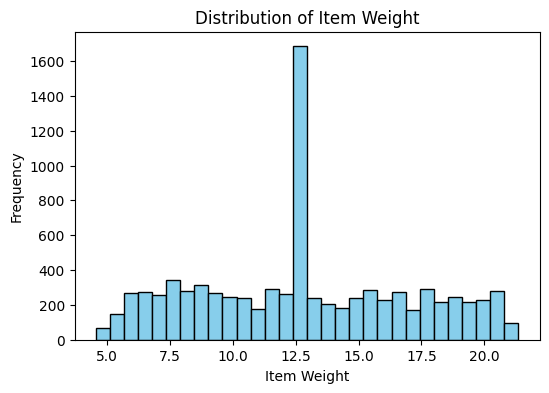

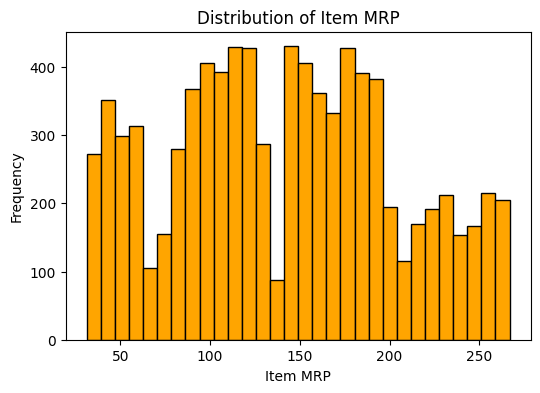

In [16]:
# Histogram for Item Weight
plt.figure(figsize=(6,4))
plt.hist(df['Item_Weight'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Item Weight")
plt.xlabel("Item Weight")
plt.ylabel("Frequency")
plt.show()

# Histogram for Item MRP
plt.figure(figsize=(6,4))
plt.hist(df['Item_MRP'], bins=30, color='orange', edgecolor='black')
plt.title("Distribution of Item MRP")
plt.xlabel("Item MRP")
plt.ylabel("Frequency")
plt.show()

### 3. Categorical Columns (Bar Plots)

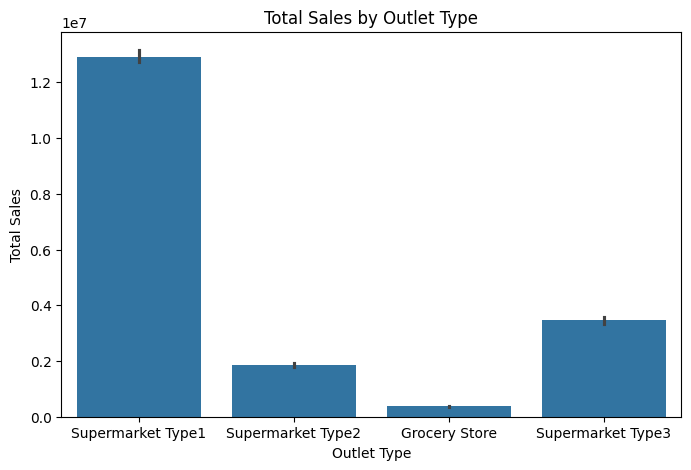

In [17]:
# Total Sales by Outlet Type
plt.figure(figsize=(8,5))
sns.barplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df, estimator=sum)
plt.title("Total Sales by Outlet Type")
plt.xlabel("Outlet Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

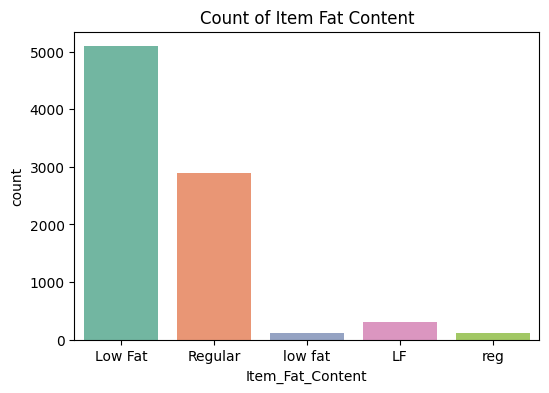

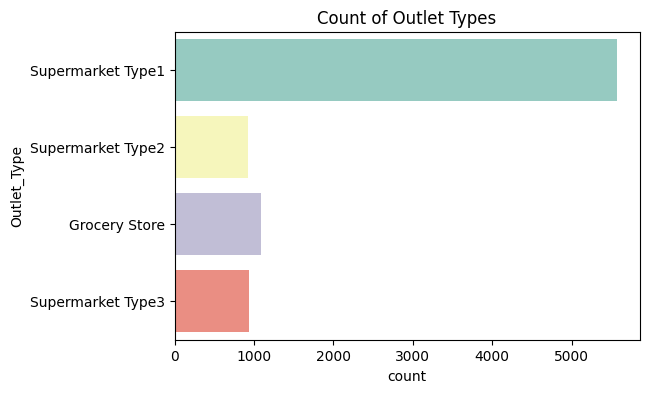

In [18]:
# Item_Fat_Content
plt.figure(figsize=(6,4))
sns.countplot(x='Item_Fat_Content', data=df, hue='Item_Fat_Content', palette='Set2', legend=False)
plt.title("Count of Item Fat Content")
plt.show()

# Outlet_Type
plt.figure(figsize=(6,4))
sns.countplot(y='Outlet_Type', data=df, hue='Outlet_Type', palette='Set3', legend=False)
plt.title("Count of Outlet Types")
plt.show()

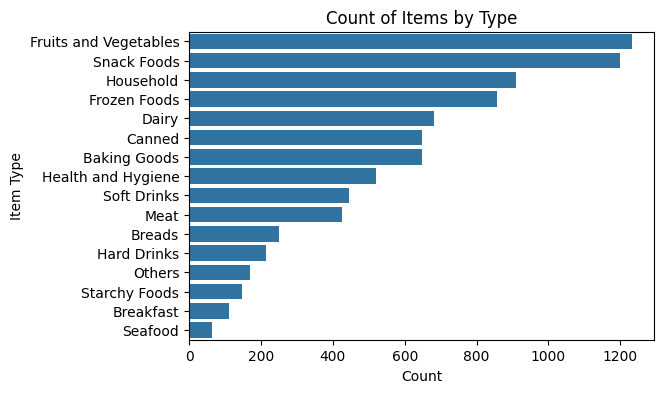

In [19]:
# Count of Item Types
plt.figure(figsize=(6,4))
sns.countplot(y='Item_Type', data=df, order=df['Item_Type'].value_counts().index)
plt.title("Count of Items by Type")
plt.xlabel("Count")
plt.ylabel("Item Type")
plt.show()

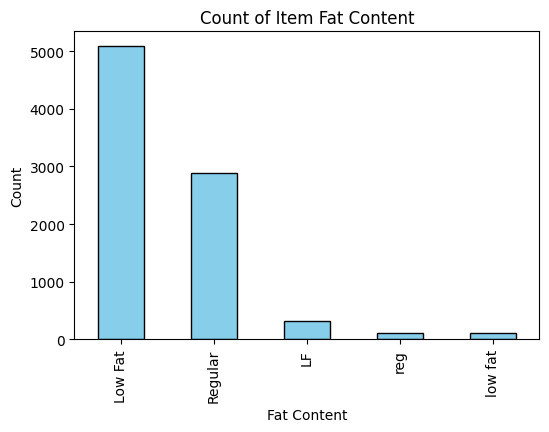

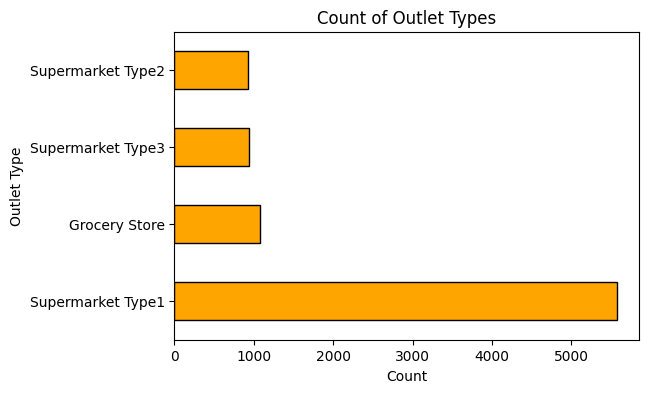

In [20]:
# Item_Fat_Content
plt.figure(figsize=(6,4))
df['Item_Fat_Content'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Count of Item Fat Content")
plt.xlabel("Fat Content")
plt.ylabel("Count")
plt.show()

# Outlet_Type
plt.figure(figsize=(6,4))
df['Outlet_Type'].value_counts().plot(kind='barh', color='orange', edgecolor='black')
plt.title("Count of Outlet Types")
plt.xlabel("Count")
plt.ylabel("Outlet Type")
plt.show()

### 4. Bivariate Analysis (Relationships)

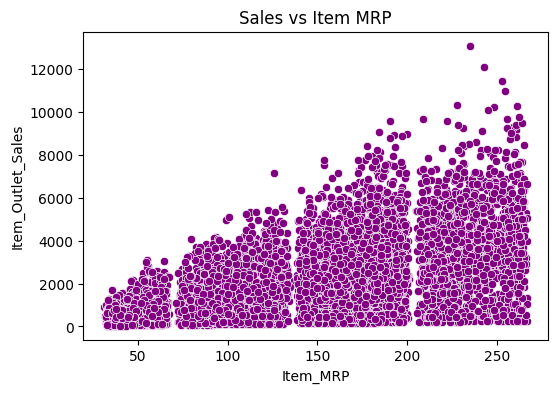

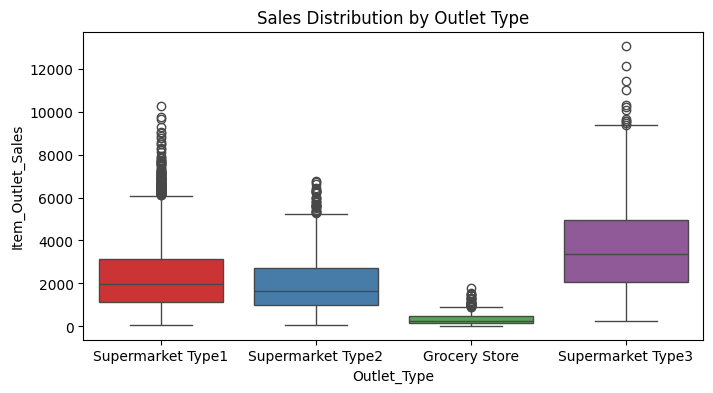

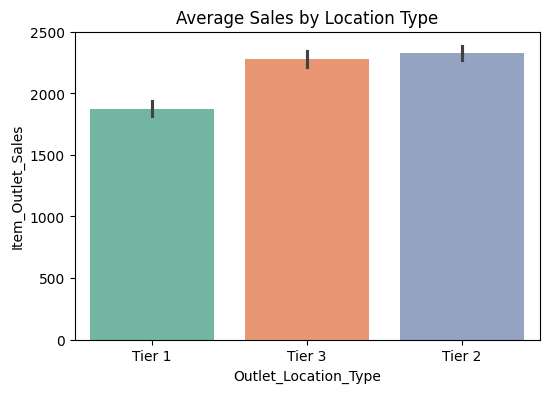

In [21]:
# Sales vs MRP (Scatterplot - Matplotlib + Seaborn)
plt.figure(figsize=(6,4))
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df, color='purple')
plt.title("Sales vs Item MRP")
plt.show()

# Sales vs Outlet Type (Boxplot with Fix)
plt.figure(figsize=(8,4))
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df, hue='Outlet_Type', palette='Set1', legend=False)
plt.title("Sales Distribution by Outlet Type")
plt.show()

# Sales vs Location (Barplot with Fix)
plt.figure(figsize=(6,4))
sns.barplot(x='Outlet_Location_Type', y='Item_Outlet_Sales', data=df, hue='Outlet_Location_Type', palette='Set2', legend=False)
plt.title("Average Sales by Location Type")
plt.show()

### 5. Correlation Analysis

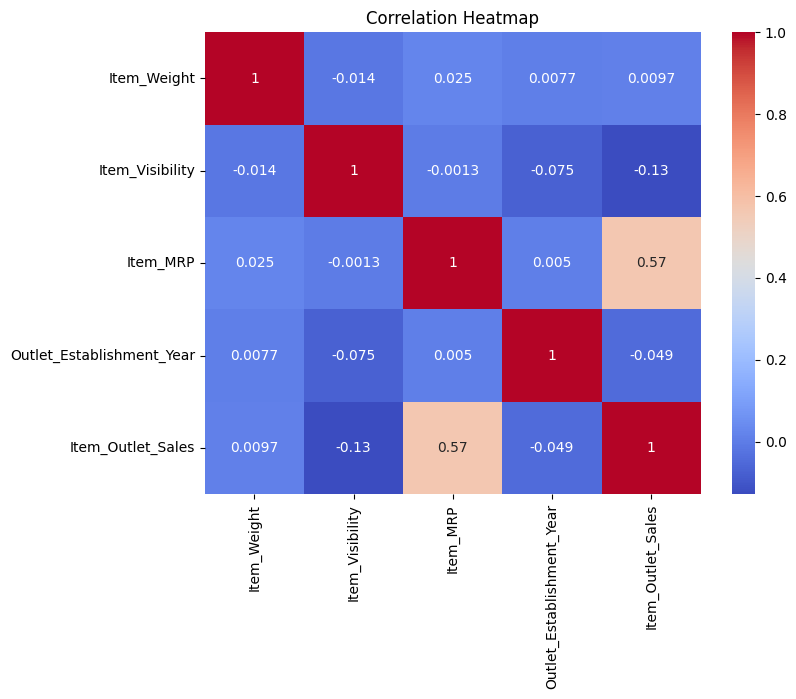

In [22]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)   # only numeric columns 
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### 6. Business Insights (KPIs)

In [23]:
# Top 5 outlets by sales
top_outlets = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 Outlets by Sales:\n", top_outlets)
print()
# Contribution of item types
item_contribution = (df.groupby('Item_Type')['Item_Outlet_Sales'].sum() / df['Item_Outlet_Sales'].sum())*100
print("Contribution of Item Types (%):\n", item_contribution)

Top 5 Outlets by Sales:
 Outlet_Identifier
OUT027    3.453926e+06
OUT035    2.268123e+06
OUT049    2.183970e+06
OUT017    2.167465e+06
OUT013    2.142664e+06
Name: Item_Outlet_Sales, dtype: float64

Contribution of Item Types (%):
 Item_Type
Baking Goods              6.807148
Breads                    2.975813
Breakfast                 1.249515
Canned                    7.767962
Dairy                     8.189897
Frozen Foods              9.820464
Fruits and Vegetables    15.168849
Hard Drinks               2.462430
Health and Hygiene        5.622038
Household                11.056317
Meat                      4.935503
Others                    1.750930
Seafood                   0.800749
Snack Foods              14.699412
Soft Drinks               4.802817
Starchy Foods             1.890156
Name: Item_Outlet_Sales, dtype: float64


# 5. Feature Engineering

### 1. Create New Columns

In [24]:
# Sales per Item
df['Sales_per_Item'] = df['Item_Outlet_Sales'] / df['Item_Weight']

# Years of Operation
df['Years_of_Operation'] = 2026 - df['Outlet_Establishment_Year']

# (Optional) Sales per Visibility
df['Sales_per_Visibility'] = df['Item_Outlet_Sales'] / (df['Item_Visibility'] + 1e-5)  # avoid divide by zero

# Verify
df[['Item_Outlet_Sales','Item_Weight','Sales_per_Item','Outlet_Establishment_Year','Years_of_Operation']].head()

,Item_Outlet_Sales,Item_Weight,Sales_per_Item,Outlet_Establishment_Year,Years_of_Operation
0,3735.1380,9.30,401.627742,1999,27
1,443.4228,5.92,74.902500,2009,17
2,2097.2700,17.50,119.844000,1999,27
3,732.3800,19.20,38.144792,1998,28
4,994.7052,8.93,111.389160,1987,39


In [25]:
# Check missing values in new engineered columns
print(df[['Sales_per_Item','Years_of_Operation','Sales_per_Visibility']].isnull().sum())

Sales_per_Item          0
Years_of_Operation      0
Sales_per_Visibility    0
dtype: int64


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  Sales_per_Item             8523 non-null   float64
 13  Years_of_Operation         8523 non-null   int64

### 2. Histogram of Sales_per_Item

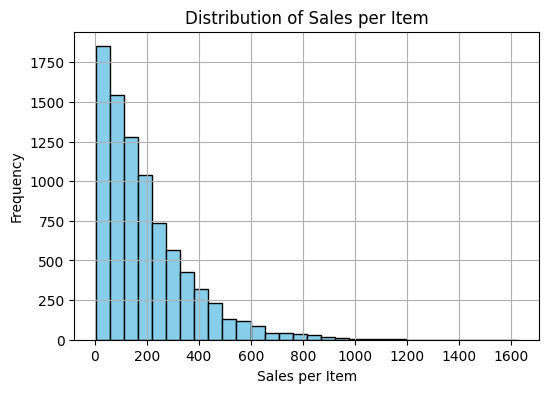

In [27]:
plt.figure(figsize=(6,4))
df['Sales_per_Item'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Sales per Item")
plt.xlabel("Sales per Item")
plt.ylabel("Frequency")
plt.show()

### 3. Scatterplot of Years_of_Operation vs Item_Outlet_Sales

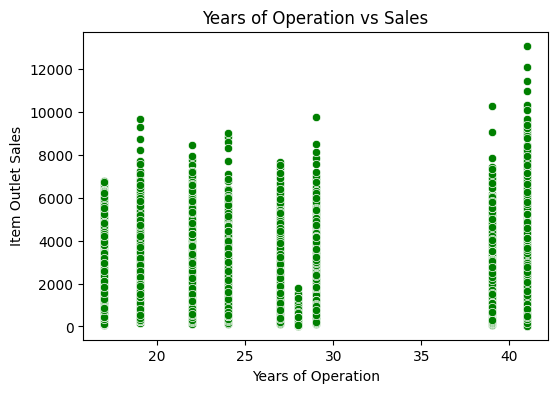

In [28]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Years_of_Operation', y='Item_Outlet_Sales', data=df, color='green')
plt.title("Years of Operation vs Sales")
plt.xlabel("Years of Operation")
plt.ylabel("Item Outlet Sales")
plt.show()

### 4. Boxplot of Sales_per_Visibility vs Outlet_Type

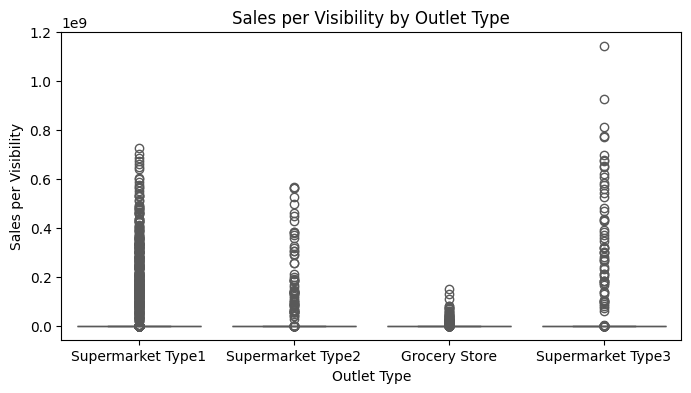

In [29]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Outlet_Type', y='Sales_per_Visibility', data=df, hue='Outlet_Type', palette='Set2', legend=False)
plt.title("Sales per Visibility by Outlet Type")
plt.xlabel("Outlet Type")
plt.ylabel("Sales per Visibility")
plt.show()